In [25]:
#packages
import requests
import pandas as pd
import json
from glob import glob
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import plotly.express as px

import geopandas as gpd

# STEP A — PCA on outage variables (tract-level)

Procedure:

    • Standardize variables
    • Run PCA
    • Keep PC1–PC3 (likely ≥60–80% variance)
    • Extract tract-level PCA scores

Figures:

    • Scree plot
    • Loading plot (which variables drive each PC)
    • Table of PCA scores by tract

In [26]:
#pulling standardized socioeconomic variables
tract_outages = pd.read_csv('data_processed/PCA_data/tract_outages.csv')
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str).str.zfill(6)

In [27]:
#Keeping derived calculations only
features_for_pca = [
    "total_outages",
    "mean_duration_hours",
    "median_duration_hours",
    "max_duration_hours",
    "total_duration_hours",
    "mean_customers_affected",
    "max_customers_affected",
    "total_customers_affected",
    "total_customer_minutes_out",
    "pct_outages_in_summer",
    "pct_outages_in_winter"
]

In [28]:
scaler = StandardScaler()

# RTP county FIPS codes
rtp_counties = ['119']  # Mecklenburg (Charlotte located in this county)

# Ensure TRACT is a string
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

# Extract county FIPS (digits 3–5)
tract_outages['county_fips'] = tract_outages['TRACT'].str[2:5]

# Keep only RTP counties
tract_outages = tract_outages[
    tract_outages['county_fips'].isin(rtp_counties)
].copy()
 

In [29]:
# Separate features and ID
X = tract_outages.drop(columns=['TRACT'])  
X = X[features_for_pca] 
X = scaler.fit_transform(X[features_for_pca])
tract_ids = tract_outages['TRACT']     

## Scree Plot

To see how many PCs to keep

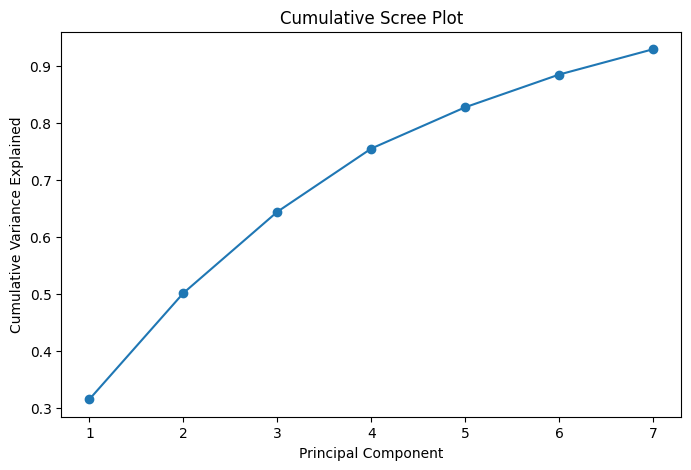

In [30]:
pca = PCA(n_components=7)
pca_scores = pca.fit_transform(X)

plt.figure(figsize=(8,5))
plt.plot(range(1, len(pca.explained_variance_ratio_)+1),
         pca.explained_variance_ratio_.cumsum(),
         marker='o')

plt.xticks(range(1, len(pca.explained_variance_ratio_)+1))
plt.xlabel("Principal Component")
plt.ylabel("Cumulative Variance Explained")
plt.title("Cumulative Scree Plot")
plt.show()

Planning on using 4 components

## Running PCA for 4 components

In [31]:
# Keeping first two principle components
pca = PCA(n_components=4)
pca_scores = pca.fit_transform(X)

In [32]:
pc_cols = ["PC1", "PC2", "PC3", "PC4"]
outages_tract_pca_scores = pd.DataFrame(pca_scores, columns=pc_cols)

# Add TRACT IDs back
outages_tract_pca_scores["TRACT"] = tract_ids.values

# Create PCA loadings dataframe
outages_tract_loadings = pd.DataFrame(
    pca.components_.T,
    index=features_for_pca,
    columns=pc_cols
)

outages_tract_loadings.to_csv("data_processed/outages_pca_results_Charlotte/outages_tract_loadings.csv", index=True)


PCA transforms correlated socioeconomic variables into a smaller number of independent components PC1, PC2, PC3, PC4

tract_outages_pca: Displays tract-level PCA scores

PCA Scores: where does each tract lie along these abstract outages axes

Loadings: which variables define each principal component (ie which pattern does PC1, PC2, PC3, and PC4 represent). The are weights linking original variables to each principal component.

## Loadings Interpretation

PC1 - High-Impact Long Duration Outages
Those with more positive PC have more total outages, long outages, medium number of customers affected, not seasonally depndent.

PC2 - Short duration outages that reach many people
There are fewer total outages, but the outages that do happen are shorter and affect a lot more people

PC3 Frequent Short Summer Outages
These ones are way more likely to happen in the summer but be very short. 

PC4 Frequent Short Winter Outages
Opposite from those that have higher PC3 scores. These happen a lot more freuqently but are also short.

# STEP B — Cluster census tracts using PCA scores

Use k-means or hierarchical clustering.

We want to:

    • Cluster tracts based on PC1, PC2, PC3, PC4 scores
    • THEN examine socioeconomic metrics within each cluster

Output per cluster:

    • Socioeconomic profile (low-income, old housing, rural, etc.)
    • Average outage frequency
    • Average outage duration
    • Weather exposure metrics
    
This gives us: which outage types disproportionately affect which communities?

## Choose k (number of clusters)
Via:
- elbow method
- silhouette score

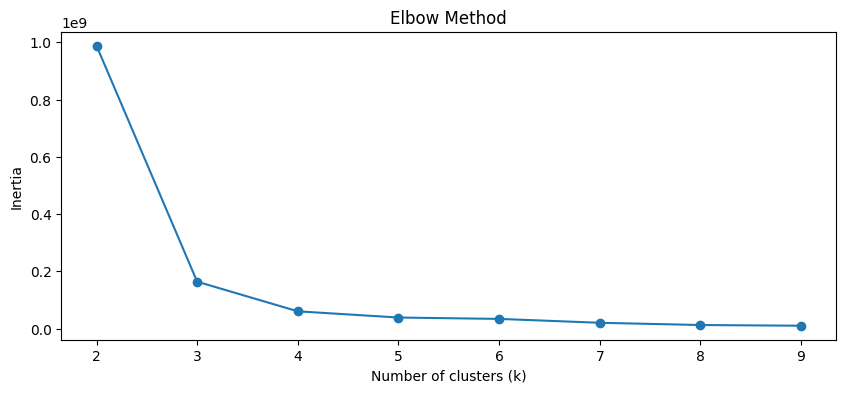

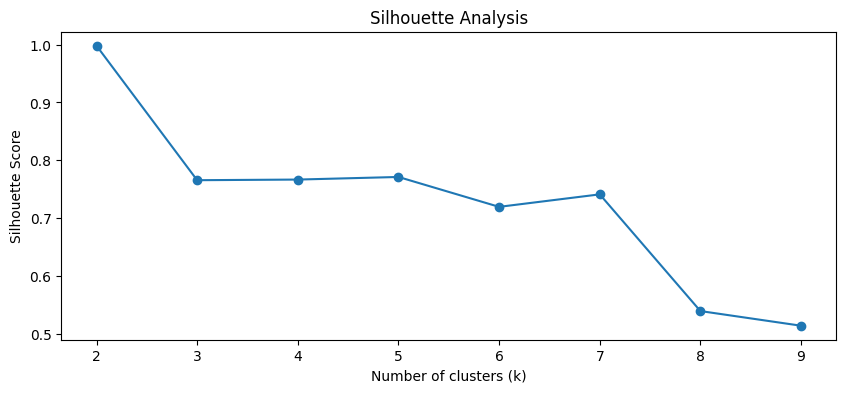

In [33]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

Ks = range(2, 10)
inertias = []
silhouettes = []

for k in Ks:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(outages_tract_pca_scores)
    
    inertias.append(kmeans.inertia_)
    silhouettes.append(silhouette_score(outages_tract_pca_scores, labels))

# Plot elbow
plt.figure(figsize=(10,4))
plt.plot(Ks, inertias, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

# Plot silhouette
plt.figure(figsize=(10,4))
plt.plot(Ks, silhouettes, marker='o')
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Analysis")
plt.show()

Choosing k = 3

- Where elbow is most visible before diminishing returns begin
- Has a higher silhouette score than k = 4, 5, 6
    - For silhouette score, it's highest at k = 2, but 2 clusters might oversimpliofy the data

## Run clustering (k-means / hierarchical)

In [34]:
best_k = 3

kmeans = KMeans(n_clusters=best_k, random_state=42)
outages_tract_pca_scores['cluster'] = kmeans.fit_predict(outages_tract_pca_scores)

## Characterize each cluster

Using the unscaled, real socioeconomic variables.

In [35]:
df = tract_outages.merge(outages_tract_pca_scores[['TRACT','cluster']], on='TRACT')

outages_cluster_profiles = df.groupby('cluster')[features_for_pca].mean()
outages_cluster_profiles.to_csv("data_processed/outages_pca_results_Charlotte/outages_cluster_profiles.csv", index=True)


Cluster 0 - Average-Impact
- I consider this to be the "average" cluster. It has the medium total number of outages, medium duration hours, medium total households affected, more outages are happening in the summer here than in the winter. But also middle of the pack in terms of household*minutes out

Cluster 1 - Low-Impact
- This one has the least amount of outages and outage duration hours, total customers affected is the least, again more outages in summer than in the winter

Cluster 2 - High-Risk, High-Impact 
- Most outages, also the longest duration, most household-minutes out, also again most of outages are in the summer

## Identify standout tracts directly using PCA scores and distances

### Identify Outliers Using PCA Distance

In [36]:
pc_df = outages_tract_pca_scores[['PC1','PC2','PC3','PC4']].copy()
pc_df['TRACT'] = outages_tract_pca_scores['TRACT']

pc_df['distance'] = np.sqrt(pc_df['PC1']**2 + pc_df['PC2']**2 + pc_df['PC3']**2 + pc_df['PC4']**2)

#Identifying 20 "outliers"
pc_df.nlargest(20, 'distance')


,PC1,PC2,PC3,PC4,TRACT,distance
32,7.985939,4.204232,-2.622401,1.203952,37119001701,9.475087
212,7.189630,3.441864,1.188725,0.452907,37119005847,8.071890
168,5.357563,5.405886,-0.097253,-2.329746,37119005616,7.960167
111,4.180826,-3.501940,2.736722,2.973634,37119004000,6.787860
29,2.487174,6.218235,-0.150641,0.032942,37119001607,6.698974
224,3.284048,1.175114,-3.798450,-3.314212,37119005859,6.130097
102,4.423394,-0.106345,2.744333,2.230368,37119003802,5.664241
244,3.916403,0.979412,-2.729929,-2.351218,37119005924,5.410933
233,4.976034,0.351583,-1.619910,-1.215843,37119005908,5.383949
97,5.142964,0.787137,0.597850,0.911118,37119003402,5.315752


### Use hierarchical clustering (Ward’s method)

Hierarchical clustering can reveal:
2 clusters at the top, then splits into smaller subgroups, no assumption of spherical boundaries

And the dendrogram helps tell a story.

Ward's method merges tracts into clusters by minimizing within-group variance. The height of each merge reflects how different two groups are.

In [37]:
from scipy.cluster.hierarchy import linkage, dendrogram, fcluster

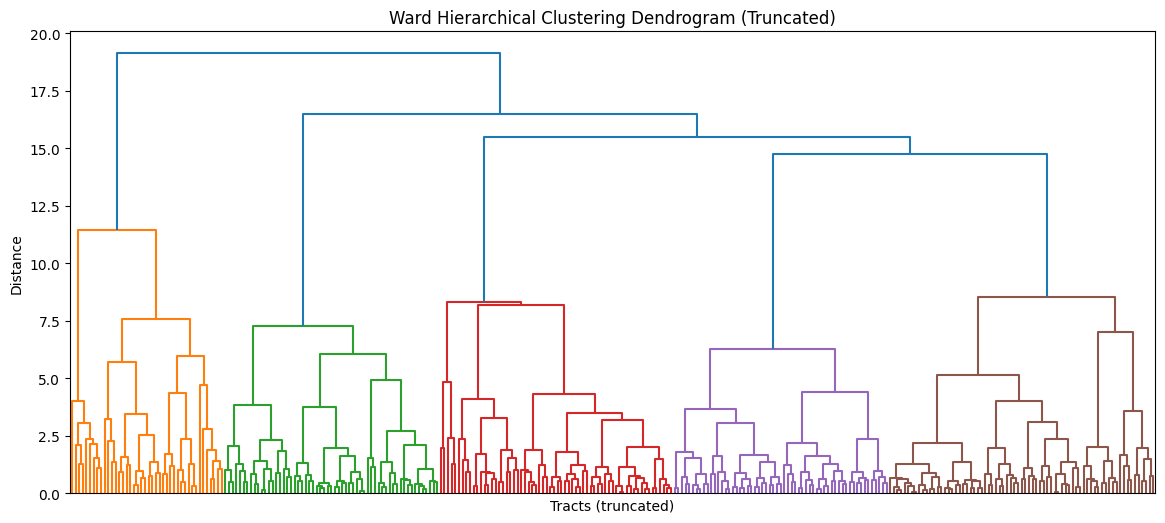

In [38]:
# Use the PCA scores for clustering
X = outages_tract_pca_scores[['PC1', 'PC2', 'PC3','PC4']].reset_index(drop=True)

# Standardize (good practice for hierarchical clustering)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

tract_ids = outages_tract_pca_scores['TRACT'].astype(str).reset_index(drop=True)

# Compute hierarchical clustering using Ward's method
Z = linkage(X_scaled, method='ward')

plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='level',  # show only top hierarchical structure
    p=30,                   # number of leaf nodes to show
    no_labels=True,
)
plt.title("Ward Hierarchical Clustering Dendrogram (Truncated)")
plt.xlabel("Tracts (truncated)")
plt.ylabel("Distance")
plt.show()

I think this dendrogram is showing maybe 3 different groups, or even just 2?

### Map PCs or SES variables directly

Map PC1–PC4

In [39]:
tract_geo = gpd.read_file("data_raw/tl_2022_37_tract")
tract_geo['TRACT'] = tract_geo['GEOID'].str[:11]  
tract_geo = tract_geo.to_crs(epsg=4326)

# Merge GeoDataFrame with PCA+cluster data
gdf = tract_geo.merge(
    outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']],
    on='TRACT',
    how='left'
)

# Drop tracts missing PCA values (if any)
gdf = gdf.dropna(subset=['PC1','PC2','PC3','PC4','cluster'])

# Ensure GeoDataFrame is in WGS84 (plotly expects EPSG:4326)
gdf = gdf.to_crs(epsg=4326)

# Save an output GeoJSON for other apps / backup
gdf.to_file("data_processed/outages_pca_results_Charlotte/outages_tracts_with_pca_and_clusters.geojson", driver="GeoJSON")
print("Saved tracts_with_pca_and_clusters.geojson")

Saved tracts_with_pca_and_clusters.geojson


PC1 - High-Impact Long Duration Outages
Those with more positive PC have more total outages, long outages, medium number of customers affected, not seasonally depndent.

PC2 - Short duration outages that reach many people
There are fewer total outages, but the outages that do happen are shorter and affect a lot more people

PC3 Frequent Short Summer Outages
These ones are way more likely to happen in the summer but be very short. 

PC4 Frequent Short Winter Outages
Opposite from those that have higher PC3 scores. These happen a lot more freuqently but are also short.

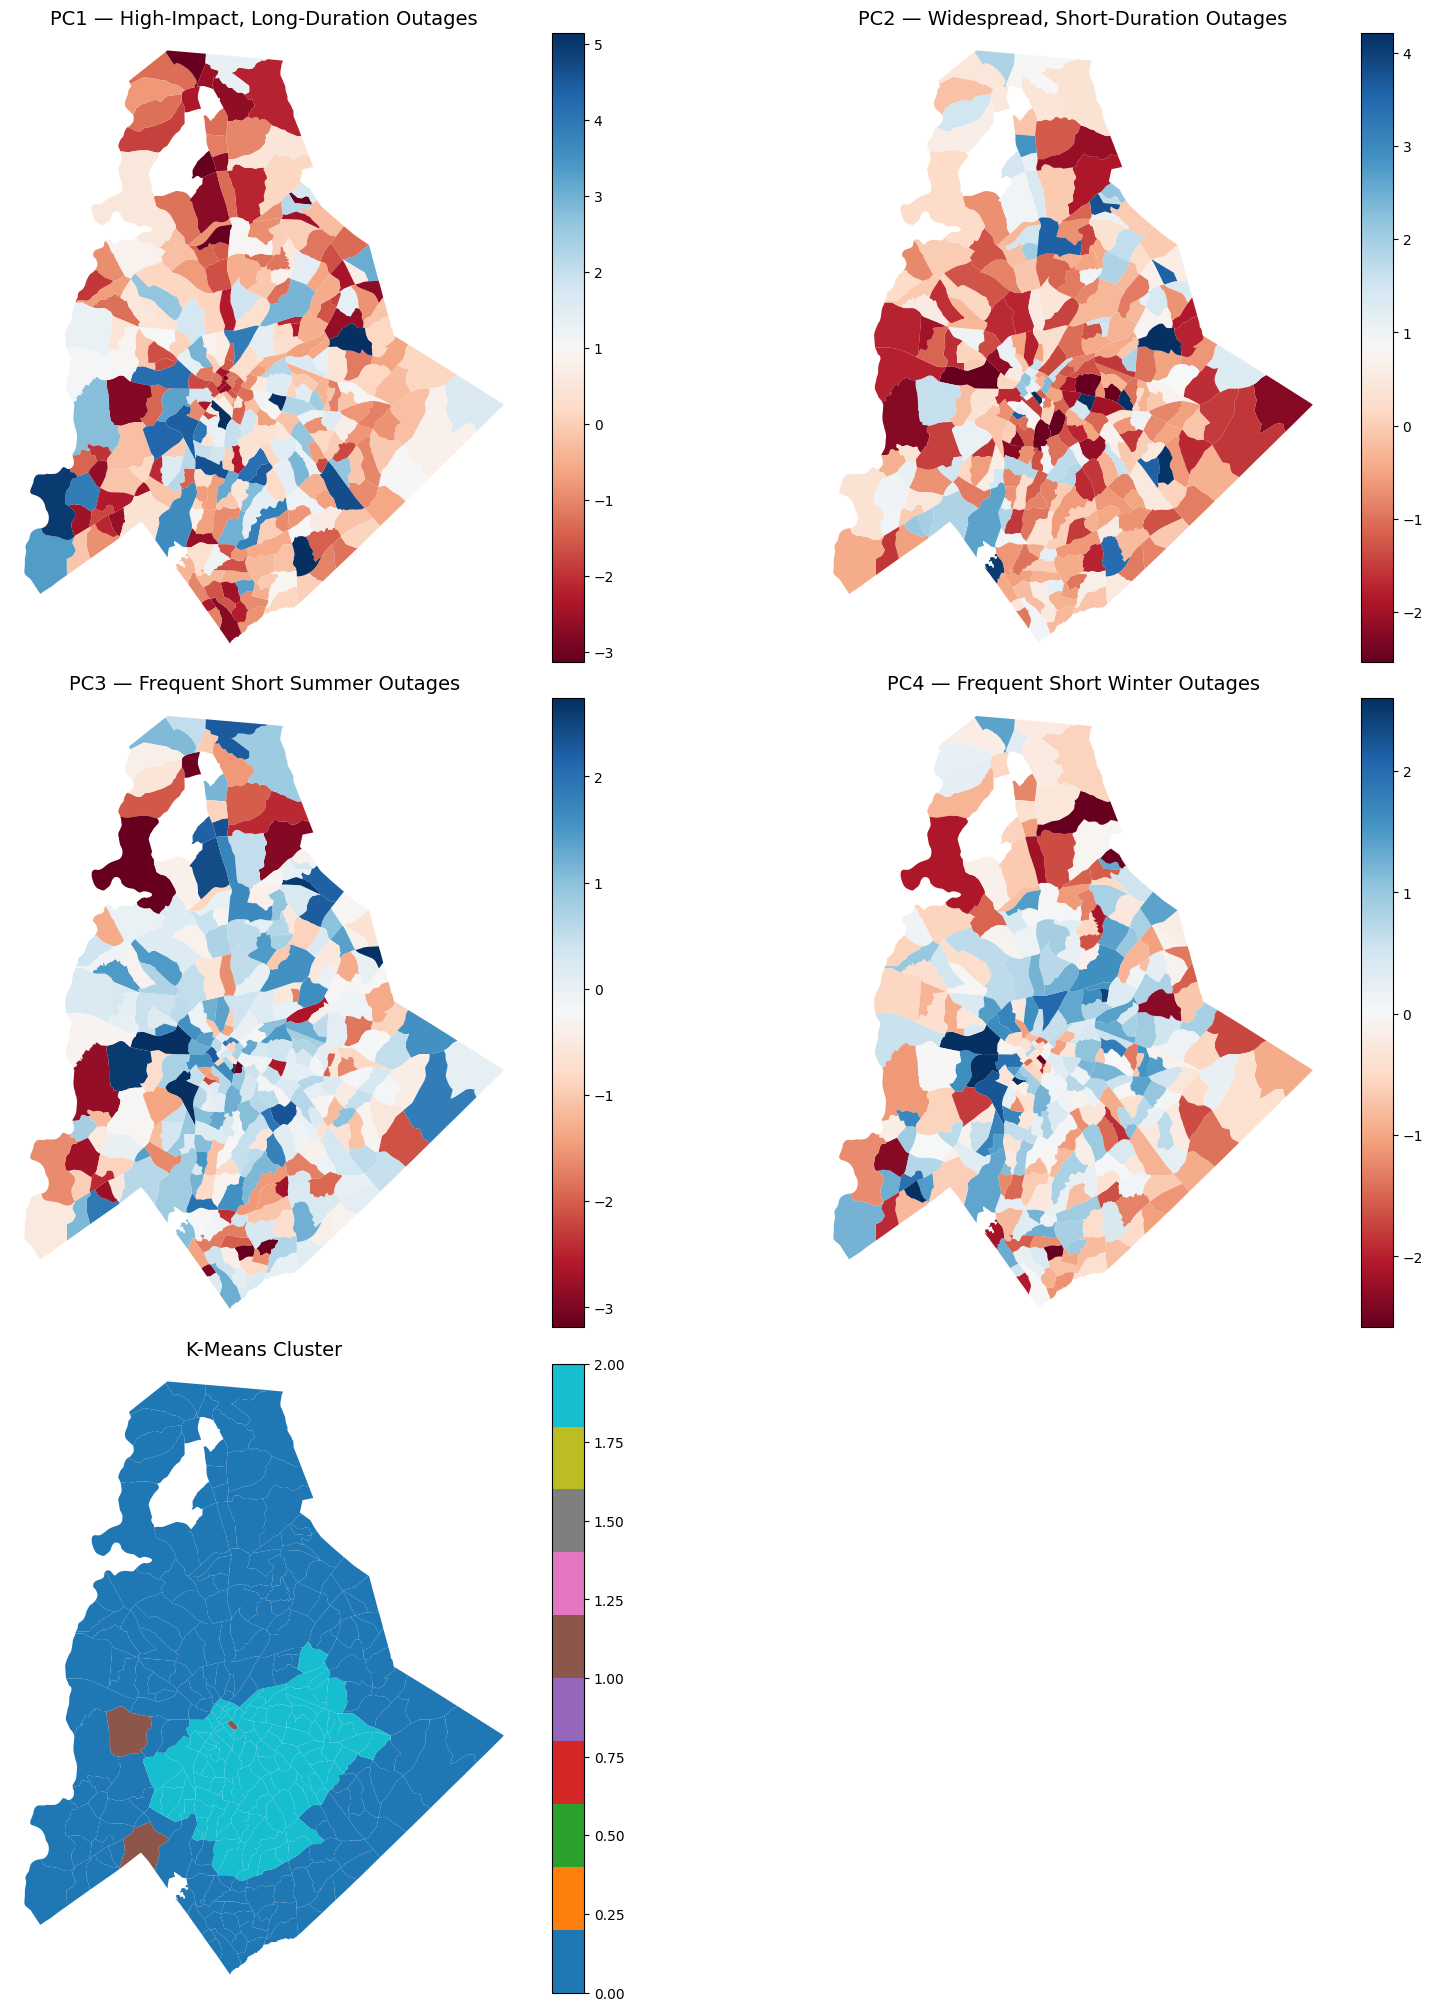

In [40]:
gdf['cluster'] = gdf['cluster'].astype(int)

variables = ['PC1','PC2','PC3','PC4','cluster']
titles = [
    'PC1 — High-Impact, Long-Duration Outages', 
    'PC2 — Widespread, Short-Duration Outages', 
    'PC3 — Frequent Short Summer Outages', 
    'PC4 — Frequent Short Winter Outages',
    'K-Means Cluster'
]

# compute global bounds and add pad so all subplots show the same full area
xmin, ymin, xmax, ymax = gdf.total_bounds
# fallback if bounds are degenerate / not finite
if not np.all(np.isfinite([xmin, ymin, xmax, ymax])):
    xmin, ymin, xmax, ymax = -1, -1, 1, 1

width = max(xmax - xmin, 1e-6)
height = max(ymax - ymin, 1e-6)
pad_x = max(width * 0.03, 0.001 * width)
pad_y = max(height * 0.03, 0.001 * height)
global_xlim = (xmin - pad_x, xmax + pad_x)
global_ylim = (ymin - pad_y, ymax + pad_y)

fig, axes = plt.subplots(3, 2, figsize=(16, 20), constrained_layout=True)
axes = axes.ravel()

for i, var in enumerate(variables):
    ax = axes[i]

    # skip if no geometries
    if gdf.geometry.is_empty.all() or gdf.geometry.isnull().all():
        ax.text(0.5, 0.5, "No geometries to plot", ha='center', va='center', transform=ax.transAxes)
        ax.set_axis_off()
        continue

    if var == 'cluster':
        gdf.plot(
            column='cluster',
            ax=ax,
            cmap='tab10',
            legend=True,
            linewidth=0,
            edgecolor='none',
            missing_kwds={"color": "lightgrey"}
        )

    else:
        # robust vmin/vmax
        col = gdf[var].replace([np.inf, -np.inf], np.nan).dropna()
        if col.empty:
            # fall back to greys if column missing
            gdf.plot(ax=ax, color='#EEEEEE', edgecolor='#BBBBBB', linewidth=0.25)
            ax.text(0.5, 0.5, f"No valid values for {var}", ha='center', va='center', transform=ax.transAxes)
        else:
            vmin = col.quantile(0.01)
            vmax = col.quantile(0.99)
            if not np.isfinite(vmin) or not np.isfinite(vmax):
                vmin, vmax = col.min(), col.max()
            if np.isclose(vmin, vmax):
                pad = abs(vmin) * 0.01 if vmin != 0 else 1e-6
                vmin -= pad
                vmax += pad

            gdf.plot(
                column=var,
                ax=ax,
                cmap='RdBu',
                legend=True,
                vmin=vmin,
                vmax=vmax,
                linewidth=0,
                edgecolor='none',
                missing_kwds={"color": "lightgrey"}
            )

    # force same geographic extent so the full map displays in every subplot
    ax.set_xlim(global_xlim)
    ax.set_ylim(global_ylim)

    ax.set_title(titles[i], fontsize=14)
    ax.set_axis_off()

# hide the unused 6th plot (if present)
if len(axes) > len(variables):
    axes[len(variables)].set_visible(False)

plt.savefig(
    'data_processed/outages_pca_results_Charlotte/charlotte_pca_maps.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

## Merge with socioeconomic + weather summaries (tract)

I have:
- tract_socioeconomic_unscaled
- tract_weather

Which are summaries of socioeconomics and weather for each tract.

This will help compute:
- Socioeconomic metrics per cluster
- Weather exposure per cluster

In [41]:
tract_socioeconomic = pd.read_csv('data_processed/PCA_data/tract_socioeconomic_unscaled.csv')
tract_weather = pd.read_csv('data_processed/PCA_data/tract_weather.csv')

# Ensure TRACT columns are strings and zero-padded
outages_tract_pca_scores['TRACT'] = outages_tract_pca_scores['TRACT'].astype(str)
tract_socioeconomic['TRACT'] = tract_socioeconomic['TRACT'].astype(str)
tract_weather['TRACT'] = tract_weather['TRACT'].astype(str)
tract_outages['TRACT'] = tract_outages['TRACT'].astype(str)

#MERGE DATSETS
# Merge PCA/cluster -> outages -> weather (left join on PCA tracts)
df = outages_tract_pca_scores[['TRACT','PC1','PC2','PC3','PC4','cluster']].merge(
    tract_socioeconomic, on='TRACT', how='left'
).merge(
    tract_weather, on='TRACT', how='left'
).merge(
    tract_outages, on = 'TRACT', how = 'left'
)


In [42]:
#DEFINING METRICS TO SUMMARIZE (from tract_socioeconomic and tract_weather)
socioeconomic_metrics = [
    'total_population',
    'median_household_income',
    'pct_below_50pct_poverty',
    'pct_no_vehicle',
    'pct_renters_cost_burdened',
    'pct_over65',
    'pct_with_disability',
    'pct_nonwhite'
]

weather_metrics = [
    'max_gust_during_outage_days',
    'mean_wind_on_outage_days',
    'total_precip_on_outage_days',
    'mean_soilmoist_on_outage_days'
]

outage_metrics = [
    'total_outages', 'mean_duration_hours',
    'median_duration_hours', 'max_duration_hours', 'total_duration_hours',
    'mean_customers_affected', 'max_customers_affected',
    'total_customers_affected', 'total_customer_minutes_out',
    'pct_outages_in_summer', 'pct_outages_in_winter'
]

#keeping metrics that exist
metrics = [m for m in (socioeconomic_metrics + weather_metrics + outage_metrics) if m in df.columns]

# Per-cluster summary table (mean, median, std, count)
agg_funcs = {m: ['mean','median','std','count'] for m in metrics}
cluster_summary = df.groupby('cluster').agg(agg_funcs)

# flatten MultiIndex columns
cluster_summary.columns = ['_'.join(col).strip() for col in cluster_summary.columns.values]
cluster_summary = cluster_summary.reset_index().sort_values('cluster')

In [43]:
# Per-cluster rates, outages per 1000 people, customer-minutes per capita
df['outages_per_1000'] = df['total_outages'] / df['total_population'] * 1000
df['customer_minutes_per_capita'] = df['total_customer_minutes_out'] / df['total_population']
per_cluster_rates = df.groupby('cluster')[['outages_per_1000','customer_minutes_per_capita']].agg(['mean','median','std']).reset_index()

# STEP C — Identify outlier clusters

Define outliers as:

    • Tracts where outage frequency/duration is > 2 standard deviations above cluster mean
    • Tracts with high weather exposure but low outages (or vice versa)

In [44]:
# Flag per-tract outliers within each cluster (z-score within cluster)
# Compute z-scores within each cluster for a small set of key metrics:
key_metrics = socioeconomic_metrics + weather_metrics
key_metrics = [m for m in key_metrics if m in df.columns]

# compute z-scores grouped by cluster
def z_within_group(group, cols):
    return group[cols].transform(lambda x: (x - x.mean()) / x.std(ddof=0))

zcols = [f"{m}_z_within_cluster" for m in key_metrics]
df[zcols] = z_within_group(df, key_metrics)

# Flag outliers: absolute z > 2 → unusual
for m, zcol in zip(key_metrics, zcols):
    df[f"{m}_is_outlier"] = df[zcol].abs() > 2

# Create an "outlier score" as sum of flags
outlier_flag_cols = [c for c in df.columns if c.endswith('_is_outlier')]
df['outlier_score'] = df[outlier_flag_cols].sum(axis=1)

# Top standout tracts by outlier_score, tiebreaker by max z magnitude
df['max_abs_z'] = df[zcols].abs().max(axis=1)
outlier_list = df.sort_values(['outlier_score','max_abs_z'], ascending=[False, False]).head(50)

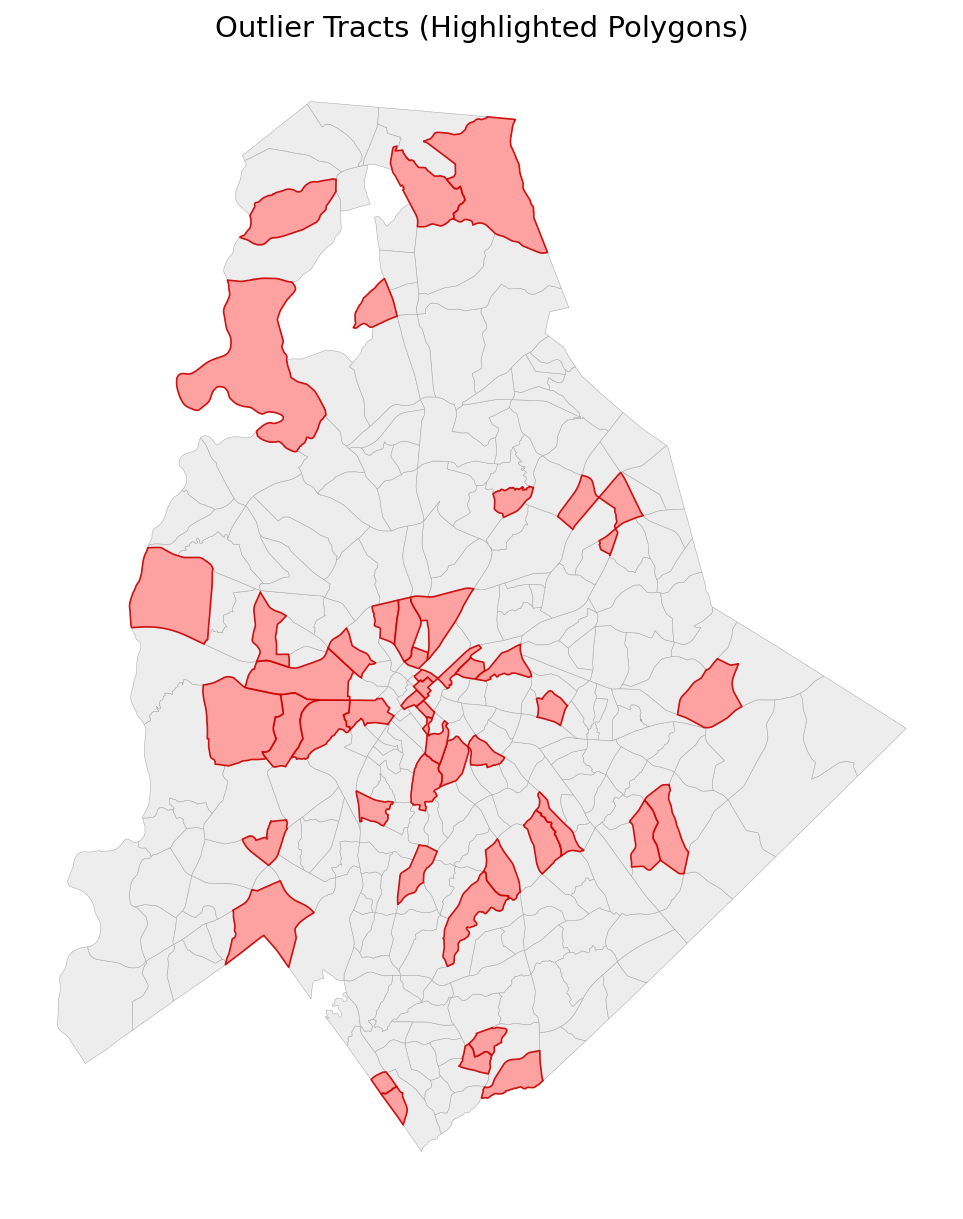

In [45]:
#gdf['TRACT'] = gdf['TRACT'].astype(str).str.zfill(6)
outlier_df = outlier_list.copy()
#outlier_df['TRACT'] = outlier_df['TRACT'].astype(str).str.zfill(6)

# Merge outlier flag into full GeoDataFrame
gdf_map = gdf.merge(
    outlier_df[['TRACT','outlier_score','max_abs_z']],
    on='TRACT',
    how='left'
)

# Outlier polygons only
outlier_gdf = gdf_map[gdf_map['outlier_score'].notna()].copy()

# Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 10), dpi=150)

# Plot all tracts in very light gray
gdf_map.plot(ax=ax, color='#EDEDED', edgecolor='#AAAAAA', linewidth=0.25)

# Highlight outlier polygons (NO centroids, NO dots)
outlier_gdf.plot(ax=ax,
                 facecolor='#ff9999',   # soft red fill
                 edgecolor='#cc0000',   # darker outline
                 linewidth=0.8,
                 alpha=0.9)

# Clean up
ax.set_axis_off()
ax.set_title("Outlier Tracts (Highlighted Polygons)", fontsize=14)

plt.savefig(
    'data_processed/outages_pca_results_Charlotte/outlier_tracts_static_map_polygons_only_outages_pca.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [46]:
#SAVE RESULTS
cluster_summary.to_csv("data_processed/outages_pca_results_Charlotte/cluster_outage_weather_summary.csv", index=False)
df.to_csv("data_processed/outages_pca_results_Charlotte/tracts_with_clusters_outage_weather.csv", index=False)
outlier_list.to_csv("data_processed/outages_pca_results_Charlotte/top50_standout_tracts.csv", index=False)
print("Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv")

Saved cluster_outage_weather_summary.csv, tracts_with_clusters_outage_weather.csv, top50_standout_tracts.csv


In [47]:
cluster_summary.columns

Index(['cluster', 'total_population_mean', 'total_population_median',
       'total_population_std', 'total_population_count',
       'median_household_income_mean', 'median_household_income_median',
       'median_household_income_std', 'median_household_income_count',
       'pct_below_50pct_poverty_mean', 'pct_below_50pct_poverty_median',
       'pct_below_50pct_poverty_std', 'pct_below_50pct_poverty_count',
       'pct_no_vehicle_mean', 'pct_no_vehicle_median', 'pct_no_vehicle_std',
       'pct_no_vehicle_count', 'pct_renters_cost_burdened_mean',
       'pct_renters_cost_burdened_median', 'pct_renters_cost_burdened_std',
       'pct_renters_cost_burdened_count', 'pct_over65_mean',
       'pct_over65_median', 'pct_over65_std', 'pct_over65_count',
       'pct_with_disability_mean', 'pct_with_disability_median',
       'pct_with_disability_std', 'pct_with_disability_count',
       'pct_nonwhite_mean', 'pct_nonwhite_median', 'pct_nonwhite_std',
       'pct_nonwhite_count', 'max_gust_du

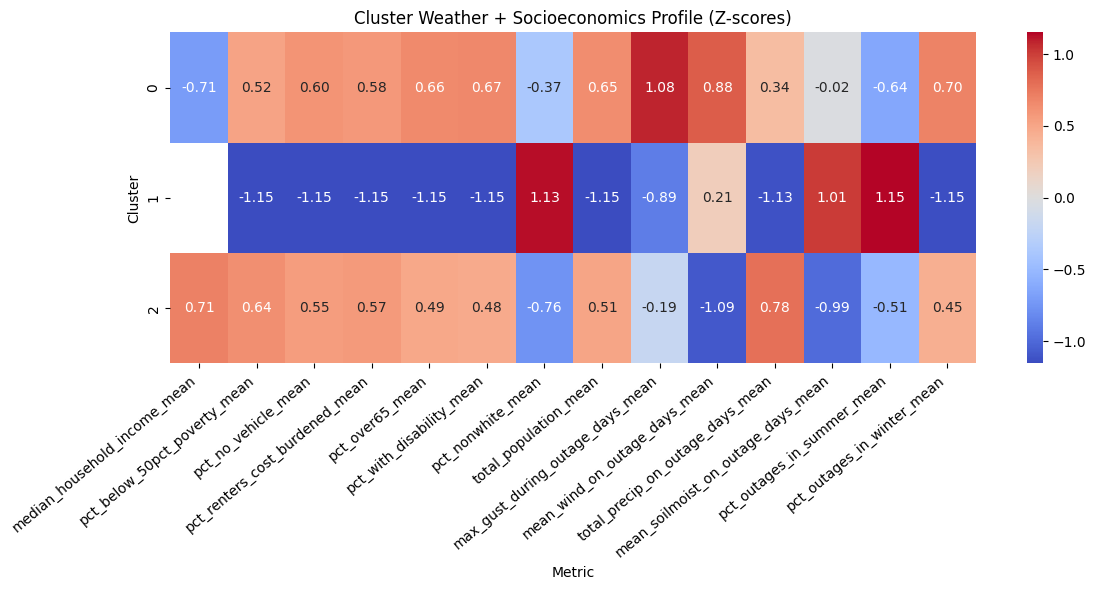

In [48]:
#image creating with the cluster summary

# Columns we want to use (as defined above)
cols = [
    'median_household_income_mean',
    'pct_below_50pct_poverty_mean',
    'pct_no_vehicle_mean',
    'pct_renters_cost_burdened_mean',
    'pct_over65_mean',
    'pct_with_disability_mean',
    'pct_nonwhite_mean',
    'total_population_mean',
    'max_gust_during_outage_days_mean',
    'mean_wind_on_outage_days_mean',
    'total_precip_on_outage_days_mean',
    'mean_soilmoist_on_outage_days_mean',
    'pct_outages_in_summer_mean',
    'pct_outages_in_winter_mean'
    
]
#cluster-level z-scores (above/below average)
cluster_summary_std = cluster_summary.copy()
cluster_summary_std[cols] = cluster_summary_std[cols].apply(
    lambda x: (x - x.mean()) / x.std()
)

import seaborn as sns

heatmap_data = cluster_summary_std.set_index('cluster')[cols]

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap="coolwarm", center=0, annot=True, fmt=".2f")
plt.title("Cluster Weather + Socioeconomics Profile (Z-scores)")
plt.xlabel("Metric")
plt.ylabel("Cluster")
plt.xticks(rotation=40, ha="right")
plt.tight_layout()

plt.savefig(
    'data_processed/outages_pca_results_Charlotte/heat_map_cluster_weather_socioeconomics.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()